# SegFormer-B2: Kaggle pretraining → Yandex domain adaptation

Ноутбук для Yandex DataSphere использует актуальную структуру репозитория:
единый `datasets.TermoDataset` читает manifests и формирует пары MAT/mask,
модель лежит в `models`, эксперимент — в `experiments/notebooks`.

Два честных результата:

1. **zero-shot**: обучение только на Kaggle, проверка на всех Yandex-видео;
2. **domain-adapted**: Kaggle checkpoint дообучается на Yandex train, threshold
   выбирается на Yandex validation, итог считается только на held-out Yandex test.

Аугментации применяются на лету и синхронно к картам и маске: horizontal flip,
vertical flip, transpose, −7°/0°/+7°, PatchReplacement. Порядок обработки:
`crop → thermal contrast3 → resize 256×256 → augmentation`.

In [1]:
# Совместимые с DataSphere Python 3.10 зависимости. PyTorch не переустанавливаем.
import base64, io, os, subprocess, sys, tarfile
from pathlib import Path

PINS = [
    "opencv-python-headless==4.10.0.84",
    "scipy==1.15.3",
    "PyYAML==6.0.2",
    "Pillow==11.3.0",
    "matplotlib==3.9.4",
    "pandas==2.2.3",
    "transformers==4.46.3",
    "kagglehub>=0.3.13,<2",
]
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--upgrade",
    "--upgrade-strategy", "only-if-needed", *PINS,
])

PROJECT_DIR = Path('/home/jupyter/filestore/thermal-control/segformer-transfer-code')
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
PAYLOAD = """H4sIAMy7hGoC/+09a3PbRpL5zF+Bw9bdAjEFk9TL5oWuZB1749rEcdnK5vZYLAQChhRWIIAAoCxGq/3t193zBkBJySbeXEJUiSQwMz0zPT39Hih4HDz+9E10/QWLElZ99ItcI37t+h6NDo/0b3w+Hk3Gk4+c648+wLWpm6iC7j/6fV6TJ866SddsNj59cjo6PTk+PQ2OJ0dPjw+PBh/tr9/8lURNVLOmfhyGaZ42YRiU219i/5+c0B4fnx6PzG+6JqPjj8ZAdOPx+PT0aAL7H25g/48+5P5na1atKvb9rnr3lf8/vVzX/SZPlylLnOaCVesocwRJOFm0ZZWzrIo1FjkVK4s6bYpq66yjNHfOqyiPLwIAMBhQpUDSkpOuy6JqnDOAV3zOHw4GYRhlWRg6M2fumiXuYs9o/n1X8KuQ/5Ou/B/t5f8Hkf8nXfl/Mhk/3Uv/35n8j4t8ma5+Ael/r/wfn4zGLfl/dHo83sv/DyT/v4pAAWB143AS2FRRkxa5sywqkvubfvWgNiR/GC43zaZiIN2F6I/yvGgITi3qYLM4i+qaKf1APRoMxJNttM4Gg8GnuoQ+nedVUT6n0U0HDlzXo6mT5o3zD+d1kTP+aNx5tO3W2tq1erpCrcTsqoyai6lTNxXdLdOMhfCoYVWun66jJrxkW/0gabYl47c9XXwV1Zc/posdo4RFMKHk0ZoZI4AKU2MyYpz1ZT01+qenMSB3aqB4QE8/pY7WrLkoEg6RLUkZDHGRvDirh3rgvnPwzHGtQbl8VHi9T5sLpyhZ7mGDoeNW7tBheVwkab6auZtmefDE9Z2odupiU8VMt8Srit6DzoidBnW0ZGFWRInHK/qqYsWA/nIHRuVZjREpM4Awd/GXuxhapYikmcaR9/HHVBUfuwvfrku4m2nUycr0vFMbcTrTKJWV8bFV1/93i9lfh/532NX/xnv974Pof6dd/e90fPx0crpXAH9X+p8S6x/c/wM019b/jg8np3v97wP7f0ynDHf7oJ9nyMV3GcWX0YodoAgW+lsdDAYvQUl8x1bwBehx3oO2WDPQFNPa4XoKyHTUIeMoL/I0Bu1xLZTNx2nD1iC2VymoD9vAcV419SAHjfGKOd99F4Yr1mCNMPzuO6iFAwGQxRoUiPQ8Y3xM+PS/HagFowHQSxahEgqdxRegWAyiPHFqtlqznGuiB3XJYphq7OQFarLpD1zRzbDPNIdu10XCsjqARkuaUNhUUV4vWfXdd8HgwequeFbUOxXfqG42ZcZ4OaiKMFpZ9DzKsghmOHS+LhFelCmA+WZdbhGjeSkfNUUVX1g3QZ4Hy00e87ZY+yXv5s2rL2Ufr9awkvxpHaflNkgLWYTKFWizYmQEcNOkgBOchaykXHrc7cfNhlahVCWFvmrSlie+/anSK6XzWStvNcuWWk2qiqIJk7QiZVM/TvM42ySg9UpczTMgpznUWSxAZ0QVX1fmawnralSX2O7WBq6QJ1GVhHX6A3RA6zUHy2GI5gNW9ybHJ0MHPoQ2RyowwphacwhUt9BG/barWH1BNeverop7AjR4miYfEyKEsGJjnhAwXwwGpq4LpYjFGvuAtWKJrSwXwPxBQQ/+XqS5J1E+JB3atyqiaYhPcddAIxwN1FRN7MrpUgFOa6x2Vze+oRkbAORCW4Bh7Yr3wLdgMkBUoorfUfCNSc+tQml60XToB0zHamEM/Rye4gjJhPGxpujeAmngG4EawNqw7amILTSz1zDQ5paFMwMOGFOSowZY0fW7CKDuZ85uEML1g8+oSnex0SaVCy4ox1h32YnvTzsIBhQCa1QAApYnNTJvz+zUNHl7YAgMNWm+YZ1CtL1p8XpmyKcn+/Y7bWuUQbpdXWawv64bT7WYjxY9HdaXvT32jttE9K6JIR7IjCRg/dVoqI/s2ibauq16pqs4SBCVYI4nniexN9TTkvQAlGTwZ0AIsGeEQIwOmOC0bXxDFU93YbVW0pwqAA9NrskPQ7A4H+PC5ozlQF9Dx7xb6J7uGC6xAdn5HDpw/rM9ooXFDKGBkHYKC/7cpErh1VkEIK63JfPyMlhCi+Zw4g9MYgBAUBTVUVVFW4+Ea0DeDjVG378LBnY2lJBouCEsT7YN0Vvg6VK1UfG5xR5bgga0L9xztjDq70k1Mvrx22jii0HMiHQQquvziXgdXHRqE8xObQGbMx3QDjYN8yZDZzR0xj7OiQryJIUNOnMOHdDLGH+2yevvN4z9wLxRB9rLAIiKVWWRRQCuM3errb1jUNTOutK45QMC/XDmnqdZmrOococtcZSu8jAuqpxV9exlBAM2/DxBz6AFwu4YNNawBv3zzABHDxLD7R9f31DFFqeVdw44Mtcsyj3fdx7zx9Bt4vnAo8bs4InPSUm4EmvUjeOWL7FN5FPcRThu2EW8tf2EqF7T8zVQyvV46GzhezsGNAql2uvsjusR7gjcDQ6Isuuxebe1yraqrOWC5LPXW2TQUzLfjqZbGND1aIrjmo6PR6MFr94qCoLgVxPzDvb5X/v8L8P/d3p0EpyMJkdPD5/sHYC/g4u7PH7J7K/7879GRyfC/zeBjX9I8d/R4d7/94H8f2+q4u8sbkg3yNCNkzHlMxNR3v0++a1ee/m/l/+m/H8yfhpMRqdH46dP97v+9yP/uyGPn1ETuFv+H0/Gx6dK/h9OUP6fjo6P9/L/A8l/Hb+Ta++UacnQyUHO379Eq1XGnDd/fY7eur9FecKunbM33/CMsGJVReXFNhgMzoxksSmFfabfqaiyGQD6zine57XKM0/SOi6uWLV9LF3ZdQDAwBIH4txAz1GS1DsiebuCf0On3ubxRVXkxaYeRBvdtnYwLhg5GYsuD5YVY07zvjgAIlgxnD+owfnKyYqi/PERv7/XRS5/X0T1RZaey9t11Kg4HSA5KdYqagfMl3cSF+VWpcYxVuL9w0KI6GOEzmTZG+xMxhZ1k3ek2r2O1qwuo7g3+viqYRWPPr5j329YDrXkOOOrya8yEPllgYrLUAclB+RcukoTVoQX72NPJak5/yDMDB2ZqkfeZ+1i4j4f+mm7dKWbmLuI0SU85Bl+s7Y7N13y9txx+R8z59DwkkdpzZy/RtmGvaiqovKW7otroOOGITkefq4SLBvhA18VjXPDwdUXUclup84NDuHW5Z39wXlrHskQWwd9a7hzvxh+OzwLnL8AIQH4GOiUVVc8vr6Msuw8ii9pd5998W1gj506m48WzjPneDzh28UoGC+cT2a9JRNZoidtYHMNezy6TmtP+PNGQ+dgzGcivGhUIBcQ3Xi0frSSD3IO6mCCWaR/L2Ty6L2eQ8AF+QTT3PHs6n4n7EHjM9yC5uO2T7DPH7iQM67XRdFchOPEq9MV7Bl7hu9T4BrvefbqzBmPe4mXV4LydXTtHUJnae7xZ8AQCWhAMebHj52J8zH8HThjX01ZtP7Eolo+G97YnB90DUR1VWRXTIyXUA1Yq0WX6BmWnXO/c405mL6YryD3ECN7FSzBoaf2rDnz3nkCZ35eZFlUwo764tszEgPAuZBF14ihAqAja4/i7zcp7BCUGVVxvuFJztQdoKjEDBYEh5ILb4ECmcOiKgNRlCZJxh6jSx6aFBkySdkU6i2BUToYEyYpWTEgbsAtAfvMOa+AYTg15qrAdsadtqqKDWwWEGn15hxg0KaHUdabsoQh184FiC9WPY4BQVXknKdRzX3zgKQcRhRfOPEFiBy0z2uHzyTbqkQBWNIkwGlAYYocAIQBooNBnQzAC587hvxADDpF7rx88462b7mhuIrM+W6gE2eZXsPoXhabKsVJpnkdSKTTNy0T0Jharm5wa0jCjAdBOHldsHR10SAZJ8iClxWKIQmE8w9JhqLsE8dkJD3c8zVDztmgJIflBH7EGwrGyW+QVxIMsRohJ1XBkViSRjknu/l0egQblD5glyKjmnkUjOLjFzQQoraIGxCIDOcbVSvcaubetTry9e6yITyT0zywptnuBoGPFLpg2x6J+Ujag+2zyRt7x09GQ3lrw4P2h3JEini7qAiCALBg9yBxIlm23BNiBXkbq7fpAuYmgfBy5Kk8CJuxfEURdNFESJCDscig4HwDCcTzRsEIZjIKxsf+0IG7yTHeHYm7E7p7OhLTwm0s8mMMxs9zYXiUDBZMoMuiSeRWk6NgNJA5DxlbQlmFVVAOiBFNzQwhvkSAcTEdWEvKD/Jou3sIAbisUer7Rn5G3RSlGAmH9Qiba3AmKD6MjwXeLDBSbRDrCKsocMpxztcC+9JLuEt94XSh2NUMlb7gz9GmroE4/pRtKjs6KXrGZYA18Iccuf8zoy9x9zdxZzU8LyrQ2c5wCNjDn75++/mLt+HbFy+/fPH8LByPxsOeNCDFuGdqygfGaHVUlUgZavGIsyZuCcA3I7BJT0Xc1+e1qg/d8AJr8eIoY2L1xsHRk8kJrA6AG2poGA/VfUIxkPAQo6Mn5gBKlYyBEjVLS6+nY6BN6hBUppMAkA0fvt+SxrDQ8aWHAPVW7Us7ENoGiB0QG2EZpWJVhQVVW2qHOjbSffqQxLiHqmTWTsTcBJn4JgclaJEP2pNPgfKEPOEAfBqECKWDPCPqevX6DIjry1evX3z2VjFjCUFlGBg82OhT/myzLxG5N4bEEzQePBwczIt3Z9YaqjF1Fw0gU5fPYJsZxRsA/0SuKCgSJegvoQAToiUs0glkmi1fOCpQ2ZTSKuJrys/f6CxLYIR4fw4cBTMVeFIDrSqx2CSNG5WBuFgo5ewbkNVWOjEl4Gj7nnQPGodzeCA1G2nC056QyoYaLHSP4/TUA98uD9aXmIuGKMibenZWbWC3MNgHTVhc0q1EdgzcR8qI1gS0nKAUx836HE3LO7OkUDYwqEn6lqcSmmnCgvvOTKuhB5acmkpDGsp7mT80aKXTqZKAZlh7fvvMFGpLL1Mw94vmJbJHqTThASaQMcDRQXjjJG9krwFmvKGNqYBLQ5MoI0LnQZgmxPNEC0xKgw1QZlHMPNdxh44bGm0kJYo56qV87CzdGwXxNsjLrav5PFZLQhM7O1uGVM1uj7sbqRYTOij10BiFQpcsbHe2A59lhaIYu6YNcmu5m5hzwynl9vENZpzZNOAjSvWIXTstT+rShr9CE0hPMprfSQ96SPZZOx+XI03mVk17UxxpncFUJc7XSoM0TF4cu22q35ms1uKvO2zA/vq6Q1N22aV2S5SK0ZWSFwKtskV/3TZFtOEK/iGFtgXjpoNJN03cqd483SxNl1MUVqIfPTXkeF3iy9Zk/J7qOFxRtT2X/uqNqK3Zj1XrtqWLeeZudCU60Pfp+sH7Cog+pCRa1QyLgmSzLmtP1MbTnzXOIarjNBW5csBI0TqdobRrHw4d6O6FsBSQ1AGDd9rd+xn39iph9JZ9v0krZh8GcSyfMGhMZZml3ChPcQ+RhCJ6a4oVQzrlkfDOiQWe0Ap4iy/Ccsq1P6DRUQB2yapKE+mxOdp1QEA0hSril12MMKAMv8zeY3qZikynxRHf7SIzGBowAO6CDvgXcMNPcLw2HyCYasvR3XyKFjLYaMKLJW9/Dsgm2J8HJs9tLYuaeWPyNk5EUmJwprP0o3xFarzoIr4o0pjVnndwimr2CD/gFzR8Txod+gSE/Ukfk2PfyhFHHypCtAfX1m5pENrlYWgGVXot1EqgubciwPAVPZ987nHtEu1UqWHibxgc9QmmRTDyu1gRAN9HVfnZEl3D3UR1hT3sqEeLXWbRqu4o011mwu26r9DXd59d181QN3Tqu8bKhcuDhyoU7YeO9fnXr9+dffb6bCjKyeE0G7XHfTd1mtv6LjLlud68otCikCV5Rq1OBi7JejoMsdoAr+NSnxr4w/5CDkazjm5/P4WJPICmtyFLViTmAUKW5hR1QleBbKv5G3k+uE8CTwXoJN9dIMSy3w+BZksQ5h4edfFJ6aXjOLBiK+YpELwk7ivRG5xnqnMJQoMSq288R++NJ7o1VK9i04RyP0I7ti6bbZill0ysnlVRK3ZGPZse6PUcUQV8IkTBCXuBKxD8zrZKjNG1FFu0fJpYyh4wdE2QttJXo5FkVkWV2OzTt+s3GPepM+CnnqCEOZhYQ0ff4KItbCbQXKtG17JeDI30TU+juttTbfZU9/VUd3uqzZ7qvp7UIs4b2B7N9UIJsBru6xbG5Eoalem2XVdsbQV8qFoq9eY5aXLvDAXmXzhMKS1gGeNtW8HWmck05+a/fniVsvd1CDQVitCcCEkN7U3X1obuPCUpxoRncsB2knqi3zlKmeb8GGWa20WtMZFb2n4CnJq3p5MkY7u5UAahWVeP9MRsZuLbb4FS75ZR0EJiljiZm9YxApzVHG2CxdTpijbkcfhyE1lPKf7oucXThmGZxpcZE3GV4b0AyBR4SOPuiT8Ogs77Gesz0EbBTzwbJlfW+bh34e48NIZMhh8bm7aIWQpTAX3OeeB/drs1VLUeUczXbW6u064GXMXEKJcn1Up+0zmXJWlr56msnpGINv2awB+cN0AUrLpiTnmxrelYvYoOogmVNtupOuPOePhQOixqdBJSZDAwPObkL+dTogiCEf7CdAlWJum6NpxoPHyRqEbo6n5IGykA+cTIv8292+h8BwDrzdoDWOQlP+7oPvZucgkG2K6dA2dt9V8eK1OH0GzilxZzB06vzxXI7+TIb4MgM9+km1a5svJlHfHAqHcr/Lh0CjUUBOsNfgTHJqYULjG8DAJCcF9edBVl/QU1Y9xEFbcNRoKX27Cs2DK9bnt+rSrkVlixYs2aatvrI9aj7HO2anfxO5yyU1TpKsXgLHGC2jlnwIiYZaiDZBRH9yn6zQeCnsy3j/9XuYwrCktq3QyQGm0yQGm+8nC6nK4waoShwnvGiEz8dtDlinJJrO3ej5k+K8f7Eax6h9ffhHrJUAUSOWfBOjkm0g2a4nzbgDkLlH/BrpMU9BrzCCaKr2kPHJOO+aFozw1d3EGYFWROlFMJl4MuDF17YTl6A9BMBPo9gD105gtfes54L9KpU0MVxLVLRAwbZQ7IcIFs5c8GDyzib70aV2icYb6H7I0/MJ23oopQK/idwVco8LxZLjPWKUOOiOKj8zyUagiF/swgbQ5Czd6DZsQwD68oStvbzNyfZiP094sOHwkIz4C27VUTNYbtLnJgsOgeGBuMFPE8F0heBOy6waXgc5xPBaCF32mAC9GuLgc2bQ+xpz2t3i4AcmZT0dBeWw5i59oG+D4CJK5ZFq3Pk4hCTVP65BQsYn6kXM5v9HPqht5CozqZYwhkcWu938ITyBLUKClRaBKYk4kZkSDYPegC98d/YV+YJYfgzUcT9WisH7WcmjgKIQfON2mWhJSf7dFnqN7wB3bsBYsvywJVLSOIJ15rKF5mIlDFMyjlOW9W6XxQmfP9sqjesXUEikNsWhhcF+Ongmb31uaCExgCoct8tYgevBZ2IGDDLDoHxjGbGO9zSSb0cHYzmjquju0j74EHgBUWN+6tbkC1J2kyuzFrT1Hcy9pTZ2w0SFegF7FwndZrsmL5GWkRLjS8zJivo1Dcr7phtCBR592JmesmqLOVYVbEPPDrxuXGVU7EsMizbUszIiQRFMyeadC/HoN5jX2AcMBC16YVeiaD+bAy76Mq4XQiXDn11LHfqdAbsOcReqMen2BWrNIGdwynvzK9hiXkG27GofsBr2OOyT7JzsuH4mA6HkXvHKDvOzSvMhTKqjiPsG6ztSfGQaKvLy3DBk+Om7qHIPs0Lzf42o3W63Jo4ngAm2K9ntjGGDOUwIy3C0kIziOsOxliHP6QPkGlPBRtgeRxrSi13AofU0vgIMZINOFK/PYvXYCj8bAJfxcCQiIhayLAcHJpTNFbLRA28MVlg4IAGs9Ack9hDy1MJ5Oa3IzTBFbEHCU5dnpjDY7A6EbNVApxo2c+ZgMwDd3siGZgtLDomdMgT2IxOvK5QTJSVEHZaLXZ8VD4wYaU9FlfFFkiVFxBChoceq8MXD2b6SZcgyZAiBH6ESBdedYwPYM8Gs8YKXB03sgParBiTAuhW/Ofd1b958Oh/vN+sApzqI2mMeY1IQYFbpoS9hH+gfrQ5JSQh6VUxkokDnydw6DXCnOhZ7RpPMwlbkp6EwT/CSJ9SR8o3AGMMWw3LTZobJVY++6aMLc4rWFqPfVbVaEmqp92vT6QxMiiON6AsrXFsVPVhozQ9nAaG4A00ICt17Xibhzl8IMcdaFg8QK7MaP3e8QVtAhBUlboIui05G1mNoDBj9/YLeqtrXeuEGeumdwG5gbCJTMIB+Gi+jgReiiuMtIBMAeP1tcC9Qjf1/LY2BcmS2iBQ5zyjdUt4EqqL/a7tedGwRH0CoN4BD8xzw5HpBcDz3/IF1oNnXPy0nEB8b6oLmGkwC65ki9WRYDVp0e89lvShkY6pAQ3MyBrJYADnolvW8ER3c/kMDSKwERYs3VRbQ3FQ4QXapBVQCntxmgE6v38qThiU4SrCvQOn1DBUD6j4BWiJBMnYxJ2BfgyuOOMopdS4M1MqcnVEITkyTxfZAfcnv6BAR17R0b2KHeGKIlHGEK5wbue2n4fhEI15sJ1swAD1ZOjy4s8PAeF6RLD/i3dCN92pRtzU/mBbe0ddJdOwd+pJfKQJ5gELjFk5qASNh5ZOTe9IomgGTj3+7EmSLHFm2FuZK/6O9e62eQsVMDvXfF6ZhgE+qkzM2/Q6DGjbMGIYtyn8Dl56qsxcRhFA1SDBjvnMSBq76IQHq1CytD93fYT3G+Yjlog+Qv2BTps3LSCdITsucC0oqhFiw474YC7CLMNrEOfPfGBGvR0MnnmHjBaTbOaXMVCD3kYlY+bp8FJTVtaL5j0TuDoOF6P7T5ezLl+sVAHhsi1Qic1PXGmA6Z0rwePc02lh/Zkvbasa5igm1+lSRrpY9EH55MDzEfAfZccAFEeHI8n+CfeoUURt4cY5UOhWRXxRS0jZ8eCs2sBI0sOhXEshIB8/EQ4dXcE4kQjSqKCwqzSgTj0qw9FyjWYmmbRsSrCEyzoZVYAR+r5jrCe8iLDw5PT4cBXrt0z8vDg/PkRW0r8vSgKek2wpH1QI4ABpAmPq6N1rJ253IeLHRjOW+3cbRVwXrmO8g0ewbHLNAnIhFv9pF3jodnEBgjMhiOKfGAu3M3l1JlXhi+KkhKu+O/LoXNFwTcCKHbQrZkjp724rVw5pSXokABx+t0hZK3NYG/KOzh0+LRbZDZr3avkt5mZv+arsMM9nYs+ycE4dIwTY+hme2Bj7l20W9PEufxAhi3URImPHXqiXlgceac1n86Otu2hd/vmE7q7uYh/XnGdm5Mzv/XceJNELkWf6THeBmkdRldRSm8x9nzhiUdvk/Jj8dYBMnc8kcyhtA/WvQVBka7F0Tr3z2++oXOGInHSlcYImpzu2dvPXr0OP3/x11fPX7iGrqHHhAkk/DExVU+dzRKuxH7P5rDNRH0tmsX2LGGMgLVKYYaeBJ8l0fpbTcX2W35vXAx4rjF7lusaiqcHVMDQlsEYrptVUEczzdvh3XAShjVD5KO9kASDNcAYwT5u5QGW4mgL6rjMjJNyFsh9k3XmmVWhKgrewnfMvnz7df4GvW3RRiNA4Uk63EDawkotoxigceVfsvgZPzII45yBaDg1BoGxN3UODM01ceKRR62k9iRdDZqB2TxEUA5a3bUIqLQq4DHk4xP+ySvjkfb0iglLWJywOwroUCMeOvi+wje24rEreOQJ2AfGgNEeNe7kCU7TvFaY5YftvTkBa3W9kNQ9M6lQbAPdgajtdtqL3RytS7D9cYMiKpHFDNQJsirk+T0zBzZN1DSVJ79peEBL0NrlR4+Qsv4MJsA7aigfym1uget1WHdikbwJLq/RVrAZzMGmIc+M4Ruhw+uYlY2DR/iIZzwE8E6AdhxSNTY4CjQJ9NT7IXEVingsMSTQNyi194CWlp/rvAABjm9LsPy0pIzptL/xUKhn5NponffkHn/glJjxt+QKNgyo7ccn4jaeVps856dlR+KEacfUMQVWT37ITzZ6/lXDx2IoZOBxOxRfat0UIbRkPS2iTVPE/LBmh6BFkUXA5iFPUJjQQdUxZ2RDMeqQzJU2tXaHIvOy5YiMvdGpR+KzRXeq291d2Hf0vynERLpna+7x/HftR78HBHEM2w8p7LoeJ6K9sQL68rCtH2DQjMbQX7NhpafWvrfKpkzQ42SXSWp/JI/WYmcgLxvQ4zzfyJ7m0eq230qrXjt8V+YpXCkOaazQUhuNnQyxVvoQbXKU+PjdStfBAWOyjpjIYxlRR/llbtR2HtDHH98sUZUNby5vof2VpcvjGyKUJt9KD4Ix5gl22cNbQLYJ3mMmC6lEbM7S+rIqegwUWbtrohiWiahkWBumHwSln50uyFE5u6Gv6egwuSUSnd2IRJI/4t0fF9PgaHnruK22pFOjjL3B1fsj/pRVsSgtNqIEfu2CIdCnOxQPsP54eev2/1MJg1qcZ1py8DdYH9k7t0euGM2leNEOG4pl4XGyzua9EdFcpY7qaC8KeJsqZQYMfN520z3tpcUhBmXj7srs7Gb78JnALh3bWUz49NlMuwF6jkK69JYUeoUBvj/KFTLT5gPnFYvEK8B7guU7Rm8HzuX+3xE5f3jUXDEQzl/Ij0ORzz4/apcDabuuh2EZ5l4fxzK67vEE6tQnHaXSNlAo6YGS7fm8+CPzvwi6qgt32vHsGdW0k4XTFEeDCYcnWeGXjHn1MBHh+LubifB5dXgIJ5/76/VlxEi8GzYi31/9jrfhj8qdbIWOf5pH7l/0JKok/p/L/L/P4r7D2O64L3Z7YdSpTpFafq9/RCzuwwNWu7fQjviICIvbabS/GJn8NpbdjMLIdzPe5XxrLbvhQbXtK3UgidtXqEMJ8OY/DOJnpMV/BIGyeesIkkwd5/W0FWT9d4wWDf+IwM3QfG9Ji8jmo0UAyPX8gOeF+600mp9wFrwvSdxKam9PU/R8x3lv0UAYd7vrGxiAZmZsqK+uzC6xq1qZM3cfF9eHmwBT+1cK76/9tb/21/7aX/trf+2v/bW/9tf+2l/7a3/tr/21v/bX/tpfH+L6P+nOdC4AoAAA"""
with tarfile.open(fileobj=io.BytesIO(base64.b64decode(PAYLOAD)), mode='r:gz') as archive:
    root = PROJECT_DIR.resolve()
    for member in archive.getmembers():
        target = (root / member.name).resolve()
        if root not in target.parents and target != root:
            raise RuntimeError(f'Unsafe bundle member: {member.name}')
    archive.extractall(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR))
print('Project code:', PROJECT_DIR)

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip


Project code: /home/jupyter/filestore/thermal-control/segformer-transfer-code


In [2]:
import torch
assert torch.cuda.is_available(), 'Выберите GPU-конфигурацию DataSphere'
print('torch:', torch.__version__)
print('GPU:', torch.cuda.get_device_name(0))
print('VRAM GiB:', torch.cuda.get_device_properties(0).total_memory / 2**30)

torch: 2.0.1+cu118
GPU: Tesla V100-PCIE-32GB
VRAM GiB: 31.7393798828125


In [3]:
# Постоянные данные и артефакты.
import shutil

FILESTORE = Path('/home/jupyter/filestore')
assert FILESTORE.is_dir() and os.access(FILESTORE, os.W_OK), FILESTORE
WORK_ROOT = FILESTORE / 'thermal-control' / 'segformer-domain-adaptation'
DATASETS_ROOT = WORK_ROOT / 'datasets_list'
CACHE_ROOT = WORK_ROOT / 'feature_cache_contrast3'
RUN_ROOT = WORK_ROOT / 'runs' / 'b2_contrast3_v1'
for path in (DATASETS_ROOT, CACHE_ROOT, RUN_ROOT):
    path.mkdir(parents=True, exist_ok=True)
print('Free GiB:', shutil.disk_usage(FILESTORE).free / 2**30)
print('Work root:', WORK_ROOT)

Free GiB: 8.30621337890625
Work root: /home/jupyter/filestore/thermal-control/segformer-domain-adaptation


In [4]:
# Kaggle PVC: ровно 38 R/Z MAT и соответствующие manual masks.
from collections import Counter
import kagglehub

KAGGLE_DOWNLOAD = WORK_ROOT / 'downloads' / 'irt-pvc-depth'
downloaded = kagglehub.dataset_download(
    'ziangwei/irt-pvc-depth', output_dir=str(KAGGLE_DOWNLOAD)
)
kaggle_root = Path(downloaded)
kaggle_mats = sorted(kaggle_root.rglob('*.mat'))
kaggle_masks = sorted(
    path for path in kaggle_root.rglob('*.png')
    if 'manual_mask' in str(path).lower()
)
expected = {
    *(f'R_{i:03d}' for i in range(2, 21)),
    *(f'Z_{i:03d}' for i in range(2, 21)),
}
mat_by_stem = {path.stem: path for path in kaggle_mats if path.stem in expected}
mask_by_stem = {path.stem: path for path in kaggle_masks if path.stem in expected}
assert set(mat_by_stem) == expected, sorted(expected - set(mat_by_stem))
assert set(mask_by_stem) == expected, sorted(expected - set(mask_by_stem))

kaggle_dir = DATASETS_ROOT / 'dataset_kaggle'
for subdir in ('data', 'masks'):
    (kaggle_dir / subdir).mkdir(parents=True, exist_ok=True)
print('Kaggle videos/masks:', len(mat_by_stem), len(mask_by_stem))
print('Kaggle source:', kaggle_root)
print('Копирование 5.7 ГБ не требуется: registry будет читать эти пути напрямую.')

Kaggle videos/masks: 38 38
Kaggle source: /home/jupyter/filestore/thermal-control/segformer-domain-adaptation/downloads/irt-pvc-depth
Копирование 5.7 ГБ не требуется: registry будет читать эти пути напрямую.


In [5]:
# Yandex: скачиваем все MAT, кроме содержимого папки «новые эксперименты».
import base64, requests
import numpy as np
from io import BytesIO
from PIL import Image

YANDEX_PUBLIC_URL = 'https://disk.yandex.ru/d/POr5765WUdKLbg'
PUBLIC_API = 'https://cloud-api.yandex.net/v1/disk/public/resources'
EXCLUDED_FOLDER = 'новые эксперименты'
YANDEX_DOWNLOAD = WORK_ROOT / 'downloads' / 'yandex'
YANDEX_DOWNLOAD.mkdir(parents=True, exist_ok=True)

def public_files(path=None):
    params = {'public_key': YANDEX_PUBLIC_URL, 'limit': 1000}
    if path is not None:
        params['path'] = path
    response = requests.get(PUBLIC_API, params=params, timeout=60)
    response.raise_for_status()
    resource = response.json()
    if resource.get('type') == 'file':
        yield resource
        return
    for item in resource.get('_embedded', {}).get('items', []):
        if item.get('type') == 'dir':
            yield from public_files(item['path'])
        else:
            yield item

def excluded(item):
    parts = str(item.get('path', '')).replace('\\', '/').split('/')[:-1]
    return any(part.strip().casefold() == EXCLUDED_FOLDER.casefold() for part in parts)

all_remote_mats = sorted(
    (item for item in public_files() if item.get('name', '').lower().endswith('.mat')),
    key=lambda item: item['path'].casefold(),
)
excluded_items = [item for item in all_remote_mats if excluded(item)]
remote_mats = [item for item in all_remote_mats if not excluded(item)]
print('Excluded folder MAT:', [item['path'] for item in excluded_items])
assert remote_mats

for number, item in enumerate(remote_mats, 1):
    destination = YANDEX_DOWNLOAD / item['name']
    expected_size = int(item.get('size') or 0)
    if destination.exists() and destination.stat().st_size > 0 and (
        not expected_size or destination.stat().st_size == expected_size
    ):
        print(f'Yandex cache {number}/{len(remote_mats)}: {destination.name}')
        continue
    url = item.get('file')
    if not url:
        metadata = requests.get(
            PUBLIC_API,
            params={'public_key': YANDEX_PUBLIC_URL, 'path': item['path']},
            timeout=60,
        )
        metadata.raise_for_status(); url = metadata.json()['file']
    partial = destination.with_suffix('.mat.part')
    print(f'Yandex download {number}/{len(remote_mats)}: {destination.name}')
    with requests.get(url, stream=True, timeout=300) as response:
        response.raise_for_status()
        with partial.open('wb') as output:
            for chunk in response.iter_content(8 * 1024 * 1024):
                if chunk: output.write(chunk)
    if expected_size and partial.stat().st_size != expected_size:
        raise IOError(destination.name)
    partial.replace(destination)

RAW_MASKS = {"Calib_Sample_1_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRElEQVR4nO3cQW7CMBRAQbfi3Fn45L0AUqEPShzPLBEK4vGxJbAyBgAAAAAAAAAAAAAAAAAAAAAAAKzh6/7D8+kLHb8/Zb76gmdwG4ubH/5Evt9y1Y0IuPtX+F/XgzurgAmMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMnA+Mp4BNYCRgJGAkYCTg7rvw8eHXN4GRgJGAC62Bx7ggExgJGAkYCQgAAAAAAMBfb4O8q/n0wQD/ykUCRgJGAu5+QvWBDeCtp8JMYCRgJGAk4IU2kbniqWATGAkYCRgJeKJNZK61/L+GCYwEjASMBIwEjASMBIwEjASMBIwEjAQ80Y8Jx1jeBd4CAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAjH39APGLCyfrTF5LAAAAAElFTkSuQmCC", "Calib_Sample_2_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRklEQVR4nO3cQa6CMBRA0X7jXtz/ctiNYwd/oLfEFs8ZGyI3D5pAdQwAAAAAAAAAAAAAAAAAAAAAAADYw9/Yw/HWpx+zD/j/Qe/jFMfMc13a7dtfYHcCRvcPrr/dr7qpTGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJOAJ+wPt/3uDCYwEjASMBIwEjE76oc1j/AoTGAkYCbjmPfB3bqomMBIwEjASEAAAAAAAgA//BvnY8h33V3grFwkYCRgJuPTurOP6C5EJjASMBIwEvP4W32PpNcgERgJGAkYCXn8ROWEpmrgImcBIwEjASMBIwEjASMBIwEjASMBIwEjAUx4mLPTEd5YLnhIAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAwXj0BV3YJdPh4Dh0AAAAASUVORK5CYII=", "Sample_10_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRElEQVR4nO3cQa6CMBRA0X7jAl0qS3Ts4A/0ltjiOWND5OZBE6iOAQAAAAAAAAAAAAAAAAAAAAAAAHv4G3s43vr0Y/YB/z/ofZzimHmuS7t9+wvsTsDo/sH1t/tVN5UJjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEPGF/oP1/bzCBkYCRgJGAkYDRST+0eYxfYQIjASMB17wH/s5N1QRGAkYCRgICAAAAAADw4d8gH1u+4/4Kb+UiASMBIwGX3p11XH8hMoGRgJGAkYDX3+J7LL0GmcBIwEjASMDrLyInLEUTFyETGAkYCRgJGAkYCRgJGAkYCRgJGAkYCXjKw4SFnvjOcsFTAgAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAMarJ/NjCkFIaSWfAAAAAElFTkSuQmCC", "Sample_11_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRElEQVR4nO3cQa6CMBRA0X7jIrtEl+nYwR/ohdjiOWND5OZBE6iOAQAAAAAAAAAAAAAAAAAAAAAAAHv4G3uYb336cfQB/z/ofZxiHnmuS7t9+wvsTsDo/sH1t/tVdygTGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJeML+QPv/3mACIwEjASMBIwGjk35o8xi/wgRGAkYCrnkP/J2bqgmMBIwEjAQEAAAAAADgw79Bnlu+4/4Kb+UiASMBIwGX3p01r78QmcBIwEjASMDrb/GdS69BJjASMBIwEvD6i8gJS9GBi5AJjASMBIwEjASMBIwEjASMBIwEjASMBDzlYcJCT3yPcsFTAgAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAMarJxZ6C/nnRpeyAAAAAElFTkSuQmCC", "Sample_12_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRElEQVR4nO3cUW7CMBQAQbfikjmhr9kLIBW6UOJ45hOhIJaHLYGVMQAAAAAAAAAAAAAAAAAAAAAAAGANX/cfnk9f6Pj9KfPVFzyD21jc/PAn8v2Wq25EwN2/wv+6HtxZBUxgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRg5HxgPAVsAiMBIwEjASMBd9+Fjw+/vgmMBIwEXGgNPMYFmcBIwEjASEAAAAAAAAD+ehvkXc2nDwb4Vy4SMBIwEnD3E6oPbABvPRVmAiMBIwEjAS+0icwVTwWbwEjASMBIwBNtInOt5f81TGAkYCRgJGAkYCRgJGAkYCRgJGAkYCTgiX5MOMbyLvAWAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAYOzrB9UXCm7k/HtEAAAAAElFTkSuQmCC", "Sample_13_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABPklEQVR4nO3cQQ6CMBRAwWK8/5XxAiyMT5TSmaWLGp/fNgpxDAAAAAAAAAAAAAAAAAAAAAAAAJjDdvzw/q2FPl/0jQWv4Dkmt//5HXmcsupCBFz9I/zT/eBgFzCBkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkfsD413AJjASMBIwEjAScPVTePvz85vASMBIwIn2wG3ckAmMBIwEjAQEAAAAAABgzYvdJ/0H6GErV+UiASMBIwFXv0P1jQPg1IPSBEYCRgJGAt7oENln/KJkAiMBIwEjAS90iOxzbf/fYQIjASMBIwEjASMBIwEjASMBIwEjASMBL/Rjwjamd4OXAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAGNdLzd+CLbvto/QAAAAAElFTkSuQmCC", "Sample_14_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRElEQVR4nO3cQa6CMBRA0X7j/rpWd+jYwR/ohdjiOWND5OZBE6iOAQAAAAAAAAAAAAAAAAAAAAAAAHv4G3uYb336cfQB/z/ofZxiHnmuS7t9+wvsTsDo/sH1t/tVdygTGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJeML+QPv/3mACIwEjASMBIwGjk35o8xi/wgRGAkYCrnkP/J2bqgmMBIwEjAQEAAAAAADgw79Bnlu+4/4Kb+UiASMBIwGX3p01r78QmcBIwEjASMDrb/GdS69BJjASMBIwEvD6i8gJS9GBi5AJjASMBIwEjASMBIwEjASMBIwEjASMBDzlYcJCT3yPcsFTAgAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAMarJ3chDCafsoxLAAAAAElFTkSuQmCC", "Sample_15_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRElEQVR4nO3cUW7CMBQAQbfikD5ijtkLIBW6UOJ45hOhIJaHLYGVMQAAAAAAAAAAAAAAAAAAAAAAAGANX/cfnk9f6Pj9KfPVFzyD21jc/PAn8v2Wq25EwN2/wv+6HtxZBUxgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRg5HxgPAVsAiMBIwEjASMBd9+Fjw+/vgmMBIwEXGgNPMYFmcBIwEjASEAAAAAAAAD+ehvkXc2nDwb4Vy4SMBIwEnD3E6oPbABvPRVmAiMBIwEjAS+0icwVTwWbwEjASMBIwBNtInOt5f81TGAkYCRgJGAkYCRgJGAkYCRgJGAkYCTgiX5MOMbyLvAWAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAYOzrBx+8C/kPgeDzAAAAAElFTkSuQmCC", "Sample_16_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRElEQVR4nO3cUW7CMBQAQbfimD5eDtoLIBW6UOJ45hOhIJaHLYGVMQAAAAAAAAAAAAAAAAAAAAAAAGANX/cfnk9f6Pj9KfPVFzyD21jc/PAn8v2Wq25EwN2/wv+6HtxZBUxgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRg5HxgPAVsAiMBIwEjASMBd9+Fjw+/vgmMBIwEXGgNPMYFmcBIwEjASEAAAAAAAAD+ehvkXc2nDwb4Vy4SMBIwEnD3E6oPbABvPRVmAiMBIwEjAS+0icwVTwWbwEjASMBIwBNtInOt5f81TGAkYCRgJGAkYCRgJGAkYCRgJGAkYCTgiX5MOMbyLvAWAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAYOzrB95YC+UCOR01AAAAAElFTkSuQmCC", "Sample_17_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRElEQVR4nO3cQa6CMBRA0X7jRl0ZW3Xs4A/0ltjiOWND5OZBE6iOAQAAAAAAAAAAAAAAAAAAAAAAAHv4G3s43vr0Y/YB/z/ofZzimHmuS7t9+wvsTsDo/sH1t/tVN5UJjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEPGF/oP1/bzCBkYCRgJGAkYDRST+0eYxfYQIjASMB17wH/s5N1QRGAkYCRgICAAAAAADw4d8gH1u+4/4Kb+UiASMBIwGX3p11XH8hMoGRgJGAkYDX3+J7LL0GmcBIwEjASMDrLyInLEUTFyETGAkYCRgJGAkYCRgJGAkYCRgJGAkYCXjKw4SFnvjOcsFTAgAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAMarJ+LjCpYqIa05AAAAAElFTkSuQmCC", "Sample_18_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRElEQVR4nO3cMY7CMBRAQS+i4f6HTUtNsQU8R9hhpkYRefqJpcQwBgAAAAAAAAAAAAAAAAAAAAAAAOzhb+zheOvTj9kH/P+g93GKY+a5Lu327S+wOwGj+wfX3+5X3VQmMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjAS8IT9gfb/vcEERgJGAkYCRgJGJ/3Q5jF+hQmMBIwEXPMe+Ds3VRMYCRgJGAkIAAAAAADAh3+DfGz5jvsrvJWLBIwEjARcenfWcf2FyARGAkYCRgJef4vvsfQaZAIjASMBIwGvv4icsBRNXIRMYCRgJGAkYCRgJGAkYCRgJGAkYCRgJOApDxMWeuI7ywVPCQAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAABivnr/bCN7BxyhTAAAAAElFTkSuQmCC", "Sample_19_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRElEQVR4nO3cQa6CMBRA0X7j3rpmd+fYwR/ohdjiOWND5OZBE6iOAQAAAAAAAAAAAAAAAAAAAAAAAHv4G3uYb336cfQB/z/ofZxiHnmuS7t9+wvsTsDo/sH1t/tVdygTGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJeML+QPv/3mACIwEjASMBIwGjk35o8xi/wgRGAkYCrnkP/J2bqgmMBIwEjAQEAAAAAADgw79Bnlu+4/4Kb+UiASMBIwGX3p01r78QmcBIwEjASMDrb/GdS69BJjASMBIwEvD6i8gJS9GBi5AJjASMBIwEjASMBIwEjASMBIwEjASMBDzlYcJCT3yPcsFTAgAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAMarJwX6DE4T9TofAAAAAElFTkSuQmCC", "Sample_20_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRElEQVR4nO3cUW7CMBQAQbfikD5ijtkLIBW6UOJ45hOhIJaHLYGVMQAAAAAAAAAAAAAAAAAAAAAAAGANX/cfnk9f6Pj9KfPVFzyD21jc/PAn8v2Wq25EwN2/wv+6HtxZBUxgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRg5HxgPAVsAiMBIwEjASMBd9+Fjw+/vgmMBIwEXGgNPMYFmcBIwEjASEAAAAAAAAD+ehvkXc2nDwb4Vy4SMBIwEnD3E6oPbABvPRVmAiMBIwEjAS+0icwVTwWbwEjASMBIwBNtInOt5f81TGAkYCRgJGAkYCRgJGAkYCRgJGAkYCTgiX5MOMbyLvAWAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAYOzrBx+8C/kPgeDzAAAAAElFTkSuQmCC", "Sample_21_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRElEQVR4nO3cUW7CMBQAQbfigDmqj9gLIBW6UOJ45hOhIJaHLYGVMQAAAAAAAAAAAAAAAAAAAAAAAGANX/cfnk9f6Pj9KfPVFzyD21jc/PAn8v2Wq25EwN2/wv+6HtxZBUxgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRg5HxgPAVsAiMBIwEjASMBd9+Fjw+/vgmMBIwEXGgNPMYFmcBIwEjASEAAAAAAAAD+ehvkXc2nDwb4Vy4SMBIwEnD3E6oPbABvPRVmAiMBIwEjAS+0icwVTwWbwEjASMBIwBNtInOt5f81TGAkYCRgJGAkYCRgJGAkYCRgJGAkYCTgiX5MOMbyLvAWAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAYOzrB4IUCkFpT937AAAAAElFTkSuQmCC", "Sample_3_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRklEQVR4nO3cQa6CMBRA0X7jarr/tbgexw7+QC/EFs8ZGyI3D5pAdQwAAAAAAAAAAAAAAAAAAAAAAADYw9/Yw3zr04+jD/j/Qe/jFPPIc13a7dtfYHcCRvcPrr/dr7pDmcBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMAT9gfa//cGExgJGAkYCRgJGJ30Q5vH+BUmMBIwEnDNe+Dv3FRNYCRgJGAkIAAAAAAAAB/+DfLc8h33V3grFwkYCRgJuPTurHn9hcgERgJGAkYCXn+L71x6DTKBkYCRgJGA119ETliKDlyETGAkYCRgJGAkYCRgJGAkYCRgJGAkYCTgKQ8TFnrie5QLnhIAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAwXj0By6kM3+/lzt0AAAAASUVORK5CYII=", "Sample_4_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRElEQVR4nO3cQa6CMBRA0X7jal0Q63Xs4A/0ltjiOWND5OZBE6iOAQAAAAAAAAAAAAAAAAAAAAAAAHv4G3s43vr0Y/YB/z/ofZzimHmuS7t9+wvsTsDo/sH1t/tVN5UJjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEPGF/oP1/bzCBkYCRgJGAkYDRST+0eYxfYQIjASMB17wH/s5N1QRGAkYCRgICAAAAAADw4d8gH1u+4/4Kb+UiASMBIwGX3p11XH8hMoGRgJGAkYDX3+J7LL0GmcBIwEjASMDrLyInLEUTFyETGAkYCRgJGAkYCRgJGAkYCRgJGAkYCXjKw4SFnvjOcsFTAgAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAMarJ0OZCsMIanwPAAAAAElFTkSuQmCC", "Sample_5_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRklEQVR4nO3cQa6CMBRA0X7jCtz/GlmDYwd/oLfEFs8ZGyI3D5pAdQwAAAAAAAAAAAAAAAAAAAAAAADYw9/Yw/HWpx+zD/j/Qe/jFMfMc13a7dtfYHcCRvcPrr/dr7qpTGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJOAJ+wPt/3uDCYwEjASMBIwEjE76oc1j/AoTGAkYCbjmPfB3bqomMBIwEjASEAAAAAAAgA//BvnY8h33V3grFwkYCRgJuPTurOP6C5EJjASMBIwEvP4W32PpNcgERgJGAkYCXn8ROWEpmrgImcBIwEjASMBIwEjASMBIwEjASMBIwEjAUx4mLPTEd5YLnhIAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAwXj0BIJEJC8sF97oAAAAASUVORK5CYII=", "Sample_6_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRElEQVR4nO3cQa6CMBRA0X7jvrp2d+bYwR/ohdjiOWND5OZBE6iOAQAAAAAAAAAAAAAAAAAAAAAAAHv4G3uYb336cfQB/z/ofZxiHnmuS7t9+wvsTsDo/sH1t/tVdygTGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJeML+QPv/3mACIwEjASMBIwGjk35o8xi/wgRGAkYCrnkP/J2bqgmMBIwEjAQEAAAAAADgw79Bnlu+4/4Kb+UiASMBIwGX3p01r78QmcBIwEjASMDrb/GdS69BJjASMBIwEvD6i8gJS9GBi5AJjASMBIwEjASMBIwEjASMBIwEjASMBDzlYcJCT3yPcsFTAgAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAMarJ5TEDHaQdILhAAAAAElFTkSuQmCC", "Sample_7_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRElEQVR4nO3cQa6CMBRA0X7jdrsaN+zYwR/ohdjiOWND5OZBE6iOAQAAAAAAAAAAAAAAAAAAAAAAAHv4G3uYb336cfQB/z/ofZxiHnmuS7t9+wvsTsDo/sH1t/tVdygTGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJGAkYCRgJeML+QPv/3mACIwEjASMBIwGjk35o8xi/wgRGAkYCrnkP/J2bqgmMBIwEjAQEAAAAAADgw79Bnlu+4/4Kb+UiASMBIwGX3p01r78QmcBIwEjASMDrb/GdS69BJjASMBIwEvD6i8gJS9GBi5AJjASMBIwEjASMBIwEjASMBIwEjASMBDzlYcJCT3yPcsFTAgAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAMarJ9+GC5CLnTc0AAAAAElFTkSuQmCC", "Sample_8_Static": "iVBORw0KGgoAAAANSUhEUgAAAUAAAADwCAAAAABURuK3AAABRElEQVR4nO3cQa6CMBRA0X7jslw+C3Ps4A/0ltjiOWND5OZBE6iOAQAAAAAAAAAAAAAAAAAAAAAAAHv4G3s43vr0Y/YB/z/ofZzimHmuS7t9+wvsTsDo/sH1t/tVN5UJjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEjASMBIwEPGF/oP1/bzCBkYCRgJGAkYDRST+0eYxfYQIjASMB17wH/s5N1QRGAkYCRgICAAAAAADw4d8gH1u+4/4Kb+UiASMBIwGX3p11XH8hMoGRgJGAkYDX3+J7LL0GmcBIwEjASMDrLyInLEUTFyETGAkYCRgJGAkYCRgJGAkYCRgJGAkYCXjKw4SFnvjOcsFTAgAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAMarJ45bCd1dHoYBAAAAAElFTkSuQmCC"}
tpu_dir = DATASETS_ROOT / 'dataset_tpu'
for subdir in ('data', 'masks'):
    (tpu_dir / subdir).mkdir(parents=True, exist_ok=True)
# Убираем только созданные нами links/files из рабочего dataset-каталога.
for path in (tpu_dir / 'data').glob('*.mat'):
    if path.is_symlink(): path.unlink()
for path in (tpu_dir / 'masks').glob('*.png'):
    path.unlink()

allowed_names = {item['name'] for item in remote_mats}
yandex_sources = [path for path in YANDEX_DOWNLOAD.glob('*.mat') if path.name in allowed_names]
for source in yandex_sources:
    destination = tpu_dir / 'data' / source.name
    destination.symlink_to(source.resolve())

required_keys = {path.stem.replace(' ', '_') for path in yandex_sources}
missing = sorted(required_keys - set(RAW_MASKS))
assert not missing, 'Нет table_mask_raw для: ' + ', '.join(missing)
for source in yandex_sources:
    key = source.stem.replace(' ', '_')
    mask = Image.open(BytesIO(base64.b64decode(RAW_MASKS[key]))).convert('L')
    assert mask.size == (320, 240)
    mask.save(tpu_dir / 'masks' / f'{source.stem}.png')
print('Yandex videos with individual masks:', len(yandex_sources))

Excluded folder MAT: ['/Новые эксперименты/Образец XIX 16 Гц.mat', '/Новые эксперименты/Пластина пласик.mat', '/Новые эксперименты/Пластина углепластик.mat']
Yandex cache 1/20: Calib Sample 1 Static.mat
Yandex cache 2/20: Calib Sample 2 Static.mat
Yandex cache 3/20: Sample 10 Static.mat
Yandex cache 4/20: Sample 11 Static.mat
Yandex cache 5/20: Sample 12 Static.mat
Yandex cache 6/20: Sample 13 Static.mat
Yandex cache 7/20: Sample 14 Static.mat
Yandex cache 8/20: Sample 15 Static.mat
Yandex cache 9/20: Sample 16 Static.mat
Yandex cache 10/20: Sample 17 Static.mat
Yandex cache 11/20: Sample 18 Static.mat
Yandex cache 12/20: Sample 19 Static.mat
Yandex cache 13/20: Sample 20 Static.mat
Yandex cache 14/20: Sample 21 Static.mat
Yandex cache 15/20: Sample 3 Static.mat
Yandex cache 16/20: Sample 4 Static.mat
Yandex cache 17/20: Sample 5 Static.mat
Yandex cache 18/20: Sample 6 Static.mat
Yandex cache 19/20: Sample 7 Static.mat
Yandex cache 20/20: Sample 8 Static.mat
Yandex videos with individu

In [6]:
# Manifests из единого dataset-слоя main. Crop выполняется до feature/resize.
import yaml

KAGGLE_MANIFEST = {
    'name': 'KaggleDataset',
    'data': {'path': 'data', 'file_pattern': '.mat', 'mat_key': 'imageArray', 'dtype': 'uint'},
    'masks': {'path': 'masks', 'file_pattern': '.png'},
    'crop': {'x0': 80, 'x1': 258, 'y0': 25, 'y1': 215},
}
TPU_MANIFEST = {
    'name': 'TPUdataset',
    'data': {'path': 'data', 'file_pattern': '.mat', 'mat_key': 'data', 'dtype': 'float32'},
    # По docs/scripts/make_tpu_masks.py: сырой кадр 240×320, crop 60 px top/bottom.
    'masks': {'path': 'masks', 'file_pattern': '.png'},
    'crop': {'x0': 0, 'x1': 320, 'y0': 60, 'y1': 180},
}
(kaggle_dir / 'manifest.yaml').write_text(yaml.safe_dump(KAGGLE_MANIFEST, sort_keys=False))
(tpu_dir / 'manifest.yaml').write_text(yaml.safe_dump(TPU_MANIFEST, sort_keys=False))

from datasets import TermoDataset
from datasets.config import DatasetConfig
kaggle_registry = TermoDataset(str(DATASETS_ROOT), include=['dataset_kaggle'])
yandex_registry = TermoDataset(str(DATASETS_ROOT), include=['dataset_tpu'])
# DataSphere хранит WORK_ROOT между запусками. Поэтому для Kaggle задаём
# канонические 38 пар явно, независимо от старого содержимого каталога.
kaggle_config = DatasetConfig.from_yaml(str(kaggle_dir / 'manifest.yaml'))
kaggle_registry.items = [
    (
        str(mat_by_stem[stem]),
        str(mask_by_stem[stem]),
        kaggle_config,
    )
    for stem in sorted(expected)
]
assert len(kaggle_registry) == 38, (
    f'Kaggle registry: ожидалось 38, найдено {len(kaggle_registry)}; '
    f'файлы: {[Path(item[0]).name for item in kaggle_registry.items]}'
)
assert len(yandex_registry) == 20, (
    f'Yandex registry: ожидалось 20, найдено {len(yandex_registry)}; '
    f'файлы: {[Path(item[0]).name for item in yandex_registry.items]}'
)
for registry in (kaggle_registry, yandex_registry):
    for mat_path, mask_path, _ in registry.items:
        assert Path(mask_path).exists(), (mat_path, mask_path)
print('Unified TermoDataset:', len(kaggle_registry), 'Kaggle |', len(yandex_registry), 'Yandex')

Unified TermoDataset: 38 Kaggle | 20 Yandex


In [7]:
# Однократный cache: HWT video → 3 local thermal-contrast maps.
from models.segformer_transfer import (
    prepare_feature_cache, split_records, train_stage,
    evaluate_checkpoint, predict_records,
)

kaggle_records = prepare_feature_cache(
    kaggle_registry, CACHE_ROOT / 'kaggle', source='kaggle'
)
yandex_records = prepare_feature_cache(
    yandex_registry, CACHE_ROOT / 'yandex', source='yandex'
)
print('Cached:', len(kaggle_records), len(yandex_records))

kaggle feature cache 33/38: Z_015
kaggle feature cache 34/38: Z_016
kaggle feature cache 35/38: Z_017
kaggle feature cache 36/38: Z_018
kaggle feature cache 37/38: Z_019
kaggle feature cache 38/38: Z_020
Cached: 38 20


In [8]:
# Split делается по исходным видео ДО on-the-fly augmentation.
SEED = 67
kaggle_split = split_records(
    kaggle_records, train_fraction=0.70, val_fraction=0.15,
    seed=SEED, stratify_prefix=True,
)
yandex_split = split_records(
    yandex_records, train_fraction=0.70, val_fraction=0.15,
    seed=SEED, stratify_mask_geometry=True,
)
print('Kaggle split:', {k: len(v) for k, v in kaggle_split.items()})
print('Yandex split:', {k: len(v) for k, v in yandex_split.items()})
print('Yandex held-out test:', [record['id'] for record in yandex_split['test']])

Kaggle split: {'train': 26, 'val': 6, 'test': 6}
Yandex split: {'train': 14, 'val': 3, 'test': 3}
Yandex held-out test: ['Calib_Sample_1_Static', 'Sample_14_Static', 'Sample_7_Static']


## Этап 1 — SegFormer-B2 pretraining на Kaggle

In [9]:
MODEL_NAME = 'nvidia/segformer-b2-finetuned-ade-512-512'
PRETRAIN_DIR = RUN_ROOT / '01_kaggle_pretrain'
if (PRETRAIN_DIR / 'metrics.json').exists():
    kaggle_metrics = json.loads((PRETRAIN_DIR / 'metrics.json').read_text())
    print('Reuse Kaggle checkpoint:', PRETRAIN_DIR / 'best.pt')
else:
    kaggle_metrics = train_stage(
        kaggle_split, PRETRAIN_DIR, model_name=MODEL_NAME,
        epochs=60, batch_size=32, workers=8, views_per_video=12,
        encoder_lr=1e-5, head_lr=5e-5, patience=12, patch_p=0.5, seed=SEED,
    )
kaggle_metrics

TRAIN_DEVICE cuda Tesla V100-PCIE-32GB


/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2026-08-18 20:15:19.757077: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-18 20:15:23.494545: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/usr/local/lib/python3.10/dist-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://git

foreground_weight 4.0
epoch=001 loss=0.8642 val_dice=0.0796 val_iou=0.0414 seconds=6.9
epoch=002 loss=0.8194 val_dice=0.1149 val_iou=0.0610 seconds=2.5
epoch=003 loss=0.7796 val_dice=0.1739 val_iou=0.0952 seconds=2.6
epoch=004 loss=0.7434 val_dice=0.2469 val_iou=0.1409 seconds=2.5
epoch=005 loss=0.7096 val_dice=0.3195 val_iou=0.1901 seconds=2.6
epoch=006 loss=0.6790 val_dice=0.3865 val_iou=0.2395 seconds=2.5
epoch=007 loss=0.6502 val_dice=0.4406 val_iou=0.2826 seconds=2.5
epoch=008 loss=0.6253 val_dice=0.4982 val_iou=0.3318 seconds=2.5
epoch=009 loss=0.5970 val_dice=0.5394 val_iou=0.3693 seconds=2.6
epoch=010 loss=0.5721 val_dice=0.5828 val_iou=0.4112 seconds=2.5
epoch=011 loss=0.5503 val_dice=0.6156 val_iou=0.4446 seconds=2.5
epoch=012 loss=0.5233 val_dice=0.6350 val_iou=0.4653 seconds=2.5
epoch=013 loss=0.4980 val_dice=0.6399 val_iou=0.4705 seconds=2.5
epoch=014 loss=0.4738 val_dice=0.6619 val_iou=0.4946 seconds=2.6
epoch=015 loss=0.4516 val_dice=0.6779 val_iou=0.5128 seconds=2.9
epo

{'checkpoint_epoch': 21,
 'threshold': 0.725,
 'validation': {'dice': 0.7182845218389874,
  'iou': 0.5604087132267233,
  'precision': 0.7124402255365695,
  'recall': 0.7242254951746904,
  'pixel_accuracy': 0.9800872802734125},
 'test': {'dice': 0.8072036617186108,
  'iou': 0.6767321761581276,
  'precision': 0.8082755075812523,
  'recall': 0.806134654818521,
  'pixel_accuracy': 0.9770762125650793}}

## Zero-shot: Kaggle checkpoint на всех Yandex-видео

In [13]:
import json
zero_shot_metrics = evaluate_checkpoint(
    PRETRAIN_DIR / 'best.pt', yandex_records,
    threshold=float(kaggle_metrics['threshold']),
    batch_size=32, workers=8, model_name=MODEL_NAME,
)
print('ZERO-SHOT YANDEX (model never saw Yandex):', json.dumps(zero_shot_metrics, indent=2))

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b2-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([150, 768, 1, 1]) in the checkpoint and torch.Size([2, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ZERO-SHOT YANDEX (model never saw Yandex): {
  "dice": 0.02971911475238586,
  "iou": 0.01508369439855319,
  "precision": 0.8777435153258158,
  "recall": 0.015115450933352852,
  "pixel_accuracy": 0.7589332580566348
}


## Этап 2 — domain adaptation на Yandex train

In [12]:
ADAPT_DIR = RUN_ROOT / '02_yandex_finetune'
if (ADAPT_DIR / 'metrics.json').exists():
    adapted_metrics = json.loads((ADAPT_DIR / 'metrics.json').read_text())
    print('Reuse adapted checkpoint:', ADAPT_DIR / 'best.pt')
else:
    adapted_metrics = train_stage(
        yandex_split, ADAPT_DIR, model_name=MODEL_NAME,
        init_checkpoint=PRETRAIN_DIR / 'best.pt',
        epochs=40, batch_size=16, workers=8, views_per_video=16,
        encoder_lr=2e-6, head_lr=1e-5, patience=10, patch_p=0.5, seed=SEED,
    )
adapted_metrics

TRAIN_DEVICE cuda Tesla V100-PCIE-32GB


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b2-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([150, 768, 1, 1]) in the checkpoint and torch.Size([2, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


foreground_weight 1.7590051643594784
epoch=001 loss=0.9011 val_dice=0.0568 val_iou=0.0293 seconds=3.0
epoch=002 loss=0.8284 val_dice=0.0648 val_iou=0.0335 seconds=2.3
epoch=003 loss=0.7784 val_dice=0.0801 val_iou=0.0417 seconds=2.3
epoch=004 loss=0.7380 val_dice=0.0900 val_iou=0.0471 seconds=2.2
epoch=005 loss=0.7128 val_dice=0.0978 val_iou=0.0514 seconds=2.3
epoch=006 loss=0.6805 val_dice=0.1072 val_iou=0.0566 seconds=2.3
epoch=007 loss=0.6512 val_dice=0.1242 val_iou=0.0662 seconds=2.2
epoch=008 loss=0.6193 val_dice=0.1439 val_iou=0.0775 seconds=2.3
epoch=009 loss=0.5874 val_dice=0.1789 val_iou=0.0983 seconds=2.2
epoch=010 loss=0.5573 val_dice=0.2230 val_iou=0.1255 seconds=2.3
epoch=011 loss=0.5311 val_dice=0.2989 val_iou=0.1757 seconds=2.3
epoch=012 loss=0.4984 val_dice=0.3808 val_iou=0.2352 seconds=2.2
epoch=013 loss=0.4679 val_dice=0.4415 val_iou=0.2833 seconds=2.2
epoch=014 loss=0.4472 val_dice=0.4947 val_iou=0.3287 seconds=2.3
epoch=015 loss=0.4158 val_dice=0.5423 val_iou=0.3720 

{'checkpoint_epoch': 40,
 'threshold': 0.6,
 'validation': {'dice': 0.7110386280180615,
  'iou': 0.5516368787101441,
  'precision': 0.7005335704756255,
  'recall': 0.7218635454846881,
  'pixel_accuracy': 0.8567097981770397},
 'test': {'dice': 0.7364816634768804,
  'iou': 0.5828816584518196,
  'precision': 0.7316902711256693,
  'recall': 0.7413362212594258,
  'pixel_accuracy': 0.8704376220702682}}

In [14]:
# Итоговая таблица. Главная строка — adapted held-out Yandex test.
import pandas as pd
rows = [
    {'stage': 'Kaggle internal test', **kaggle_metrics['test']},
    {'stage': 'Yandex zero-shot (all 20)', **zero_shot_metrics},
    {'stage': 'Yandex adapted held-out test', **adapted_metrics['test']},
]
comparison = pd.DataFrame(rows)
display(comparison.style.format({c: '{:.4f}' for c in comparison.columns if c != 'stage'}))
comparison.to_csv(RUN_ROOT / 'comparison.csv', index=False)

,stage,dice,iou,precision,recall,pixel_accuracy
0,Kaggle internal test,0.8072,0.6767,0.8083,0.8061,0.9771
1,Yandex zero-shot (all 20),0.0297,0.0151,0.8777,0.0151,0.7589
2,Yandex adapted held-out test,0.7365,0.5829,0.7317,0.7413,0.8704


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b2-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([150, 768, 1, 1]) in the checkpoint and torch.Size([2, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b2-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([150, 768, 1, 1]) in the checkpoint and torch.Size([2, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([150]) in 

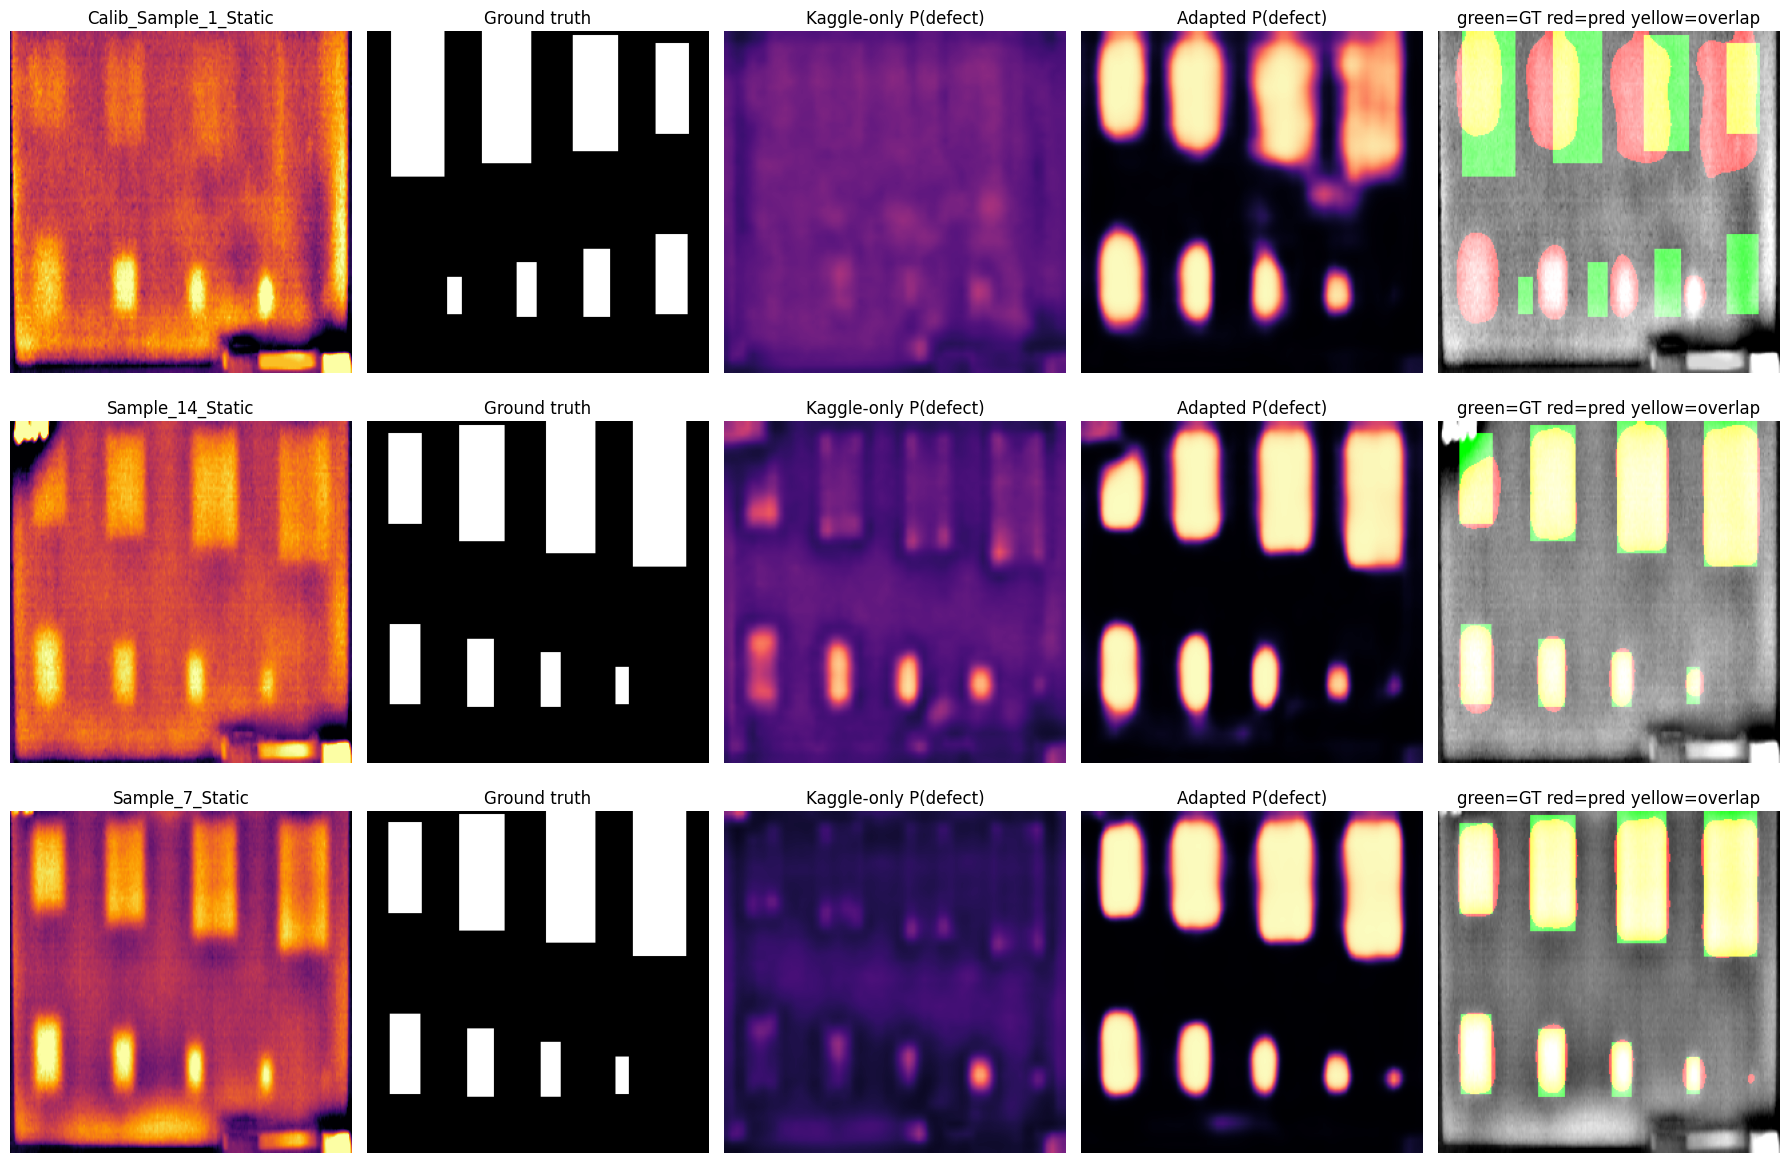

/home/jupyter/filestore/thermal-control/segformer-domain-adaptation/runs/b2_contrast3_v1/heldout_yandex_before_after.png


In [15]:
# Одинаковые held-out Yandex test-видео: до и после domain adaptation.
import matplotlib.pyplot as plt

zero_predictions = predict_records(
    PRETRAIN_DIR / 'best.pt', yandex_split['test'],
    threshold=float(kaggle_metrics['threshold']), model_name=MODEL_NAME,
)
adapted_predictions = predict_records(
    ADAPT_DIR / 'best.pt', yandex_split['test'],
    threshold=float(adapted_metrics['threshold']), model_name=MODEL_NAME,
)
fig, axes = plt.subplots(len(zero_predictions), 5, figsize=(18, 4 * len(zero_predictions)), squeeze=False)
for row, (before, after) in enumerate(zip(zero_predictions, adapted_predictions)):
    feature = before['image'].mean(0)
    lo, hi = np.percentile(feature, [1, 99])
    feature = np.clip((feature - lo) / max(hi - lo, 1e-6), 0, 1)
    axes[row, 0].imshow(feature, cmap='inferno'); axes[row, 0].set_title(before['id'])
    axes[row, 1].imshow(before['mask'], cmap='gray'); axes[row, 1].set_title('Ground truth')
    axes[row, 2].imshow(before['probability'], cmap='magma', vmin=0, vmax=1)
    axes[row, 2].set_title('Kaggle-only P(defect)')
    axes[row, 3].imshow(after['probability'], cmap='magma', vmin=0, vmax=1)
    axes[row, 3].set_title('Adapted P(defect)')
    overlay = np.repeat(feature[..., None], 3, axis=-1)
    overlay[after['mask'].astype(bool), 1] = 1
    overlay[after['prediction'].astype(bool), 0] = 1
    axes[row, 4].imshow(overlay); axes[row, 4].set_title('green=GT red=pred yellow=overlap')
    for axis in axes[row]: axis.axis('off')
plt.tight_layout()
visual_path = RUN_ROOT / 'heldout_yandex_before_after.png'
plt.savefig(visual_path, dpi=160, bbox_inches='tight'); plt.show()
print(visual_path)

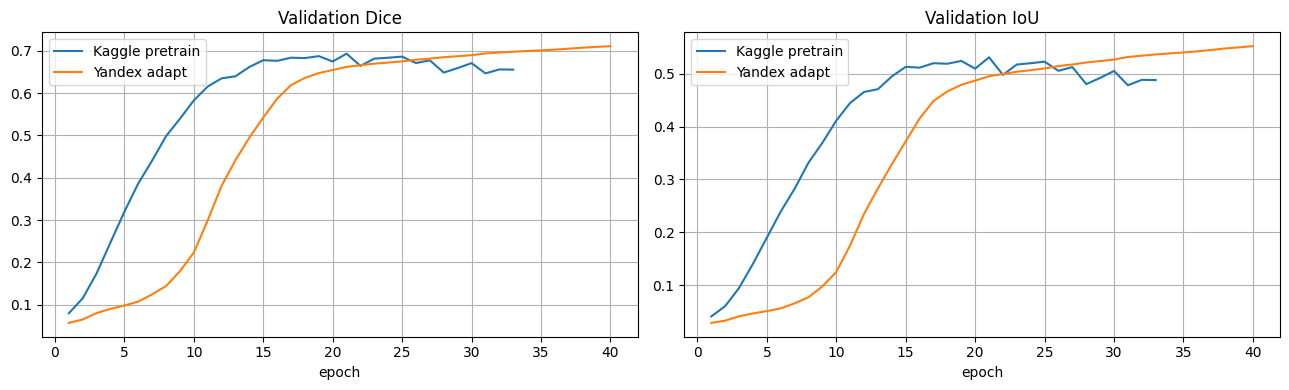

In [16]:
# Кривые обоих этапов.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label, directory in [('Kaggle pretrain', PRETRAIN_DIR), ('Yandex adapt', ADAPT_DIR)]:
    history = json.loads((directory / 'history.json').read_text())
    axes[0].plot([x['epoch'] for x in history], [x['val_dice'] for x in history], label=label)
    axes[1].plot([x['epoch'] for x in history], [x['val_iou'] for x in history], label=label)
for axis, title in zip(axes, ['Validation Dice', 'Validation IoU']):
    axis.set_title(title); axis.set_xlabel('epoch'); axis.grid(); axis.legend()
plt.tight_layout(); plt.show()

In [17]:
# Архив checkpoints, split, metrics и визуализации.
archive_path = shutil.make_archive(str(RUN_ROOT), 'zip', root_dir=RUN_ROOT)
print('Result archive:', archive_path)

Result archive: /home/jupyter/filestore/thermal-control/segformer-domain-adaptation/runs/b2_contrast3_v1.zip


## Как интерпретировать

- `Yandex zero-shot` отвечает на вопрос о переносе без использования Yandex в loss.
- Главный practically useful результат — `Yandex adapted held-out test`: эти test
  ролики не участвовали ни в обучении, ни в подборе threshold.
- Нельзя сообщать метрику на Yandex train как итоговую.
- Если adapted test всё ещё низкий, следующий проверяемый фактор — корректность
  source-specific crop/temporal alignment, а не повторный запуск с другим seed.